# Midterm: WC's portion
### Mapping housing vintage / Group: Coast Live Oaks

##### Research Question: What is the relationship between coast live oak presence and neighborhood characteristics in LA County? My focus: housing vintage. 
##### Data Sources: ACS 5-year 2022, Tiger/Line 2022, iNaturalist

First I import all the libraries I will use. 

In [1]:
# for wrangling data and geospatial data
import pandas as pd
import geopandas as gpd

# for interactive charts and maps
import plotly.express as px
import folium

# for improving visuals
import matplotlib.pyplot as plt
from matplotlib import colormaps

# for adding basemaps
import contextily as ctx

I define my dataframes and read my files. 

In [2]:
# define dataframes

# read csv of ACS data on housing characteristics
df = pd.read_csv('/home/jovyan/coastliveoak/Group Data/housingData-ACS2022.csv')

# read Tiger/Line shapefile
tracts = gpd.read_file('/home/jovyan/coastliveoak/Group Data/tigerLine-tracts-2022.zip')

# read iNaturalist csv
oaks = pd.read_csv('/home/jovyan/coastliveoak/Group Data/coastliveoaksobservations.csv')

I inspect the ACS data. 

In [3]:
df.FIPS.head()

0    6037101110
1    6037101122
2    6037101220
3    6037101221
4    6037101222
Name: FIPS, dtype: int64

I solve the leading-zero problem with a function. 

In [4]:
# with arguments, function can be applied to other columns
def add_leading_zero(column, items):
    df[column] = df[column].astype(str).str.zfill(items) # convert column to string and use zfill to add leading zero

add_leading_zero('FIPS', 11)

I check to see that the zeros were added. 

In [5]:
df.FIPS.head()

0    06037101110
1    06037101122
2    06037101220
3    06037101221
4    06037101222
Name: FIPS, dtype: object

Now it's time to subset my data. The first subset will contain housing vintage. 

In [6]:
# create list
columns_vintage = [
                        'FIPS',
                        'DP04_0016E',
                        'DP04_0017E',
                    	'DP04_0018E',
                        'DP04_0019E',
                        'DP04_0020E',
                    	'DP04_0021E',
                    	'DP04_0022E',
                        'DP04_0023E',
                        'DP04_0024E',
                        'DP04_0025E',
                        'DP04_0026E'
]

# define subset
df_vintage = df[columns_vintage]

In [7]:
list(df_vintage)
columns = list(df_vintage)

# rename columns
df_vintage.columns = [
                     'FIPS',
                     'Total Housing Units',
                     '2020 or Later',
                     '2010 to 2019',
                     '2000 to 2009',
                     '1990 to 1999',
                     '1980 to 1989',
                     '1970 to 1979',
                     '1960 to 1969',
                     '1950 to 1959',
                     '1940 to 1949',
                     '1939 or Earlier'
]

df_vintage.head()

,FIPS,Total Housing Units,2020 or Later,2010 to 2019,2000 to 2009,1990 to 1999,1980 to 1989,1970 to 1979,1960 to 1969,1950 to 1959,1940 to 1949,1939 or Earlier
0,06037101110,1652,0,39,48,87,79,119,213,516,223,328
1,06037101122,1427,0,5,247,35,68,176,469,286,31,110
2,06037101220,1372,9,32,58,81,72,231,187,232,306,164
3,06037101221,1549,0,35,113,353,191,300,221,83,78,175
4,06037101222,1006,0,35,0,11,445,138,98,162,45,72


Now I merge my subsetted dataframe with the Tiger/Line data. 

In [8]:
tracts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9129 entries, 0 to 9128
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   9129 non-null   object  
 1   COUNTYFP  9129 non-null   object  
 2   TRACTCE   9129 non-null   object  
 3   GEOID     9129 non-null   object  
 4   NAME      9129 non-null   object  
 5   NAMELSAD  9129 non-null   object  
 6   MTFCC     9129 non-null   object  
 7   FUNCSTAT  9129 non-null   object  
 8   ALAND     9129 non-null   int64   
 9   AWATER    9129 non-null   int64   
 10  INTPTLAT  9129 non-null   object  
 11  INTPTLON  9129 non-null   object  
 12  geometry  9129 non-null   geometry
dtypes: geometry(1), int64(2), object(10)
memory usage: 927.3+ KB


In [9]:
tracts.GEOID.head()

0    06037137504
1    06037138000
2    06037139200
3    06087120901
4    06087120902
Name: GEOID, dtype: object

In [10]:
tracts = tracts[['GEOID','geometry']]
tracts.head()

,GEOID,geometry
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.58099 34.1..."
1,06037138000,"POLYGON ((-118.60573 34.14585, -118.60561 34.1..."
2,06037139200,"POLYGON ((-118.53082 34.18024, -118.52952 34.1..."
3,06087120901,"POLYGON ((-122.04607 37.07105, -122.04505 37.0..."
4,06087120902,"POLYGON ((-122.02513 37.0432, -122.025 37.0432..."


In [11]:
# merge tracts_vintage with df_vintage on the FIPS column
tracts_vintage = tracts.merge(df_vintage, left_on='GEOID', right_on='FIPS')

# view vintage dataframe to check that merge is complete
tracts_vintage.head(1)

,GEOID,geometry,FIPS,Total Housing Units,2020 or Later,2010 to 2019,2000 to 2009,1990 to 1999,1980 to 1989,1970 to 1979,1960 to 1969,1950 to 1959,1940 to 1949,1939 or Earlier
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.58099 34.1...",06037137504,702,0,0,3,7,24,251,214,151,20,32


Now I want to create buckets of housing vintage. There are 9 vintage columns; I'm going to group them into 5 buckets.  

In [16]:
# Create percentage columns
tracts_vintage['% 1940s and Earlier'] = (tracts_vintage['1939 or Earlier'] + tracts_vintage['1940 to 1949']) / tracts_vintage['Total Housing Units'] * 100
tracts_vintage['% 1950s-1960s'] = (tracts_vintage['1950 to 1959'] + tracts_vintage['1960 to 1969']) / tracts_vintage['Total Housing Units'] * 100
tracts_vintage['% 1970s-1980s'] = (tracts_vintage['1970 to 1979'] + tracts_vintage['1980 to 1989']) / tracts_vintage['Total Housing Units'] * 100
tracts_vintage['% 1990s-2000s'] = (tracts_vintage['1990 to 1999'] + tracts_vintage['2000 to 2009'] ) / tracts_vintage['Total Housing Units'] * 100
tracts_vintage['% 2010s and Later'] = (tracts_vintage['2010 to 2019'] + tracts_vintage['2020 or Later']) / tracts_vintage['Total Housing Units'] * 100

tracts_vintage.head(1)

,GEOID,geometry,FIPS,Total Housing Units,2020 or Later,2010 to 2019,2000 to 2009,1990 to 1999,1980 to 1989,1970 to 1979,1960 to 1969,1950 to 1959,1940 to 1949,1939 or Earlier,% 1940s and Earlier,% 1950s-1960s,% 1970s-1980s,% 1990s-2000s,% 2010s and Later
0,06037137504,"POLYGON ((-118.58119 34.14318, -118.58099 34.1...",06037137504,702,0,0,3,7,24,251,214,151,20,32,7.407407,51.994302,39.173789,1.424501,0.0


Now I'll define a 

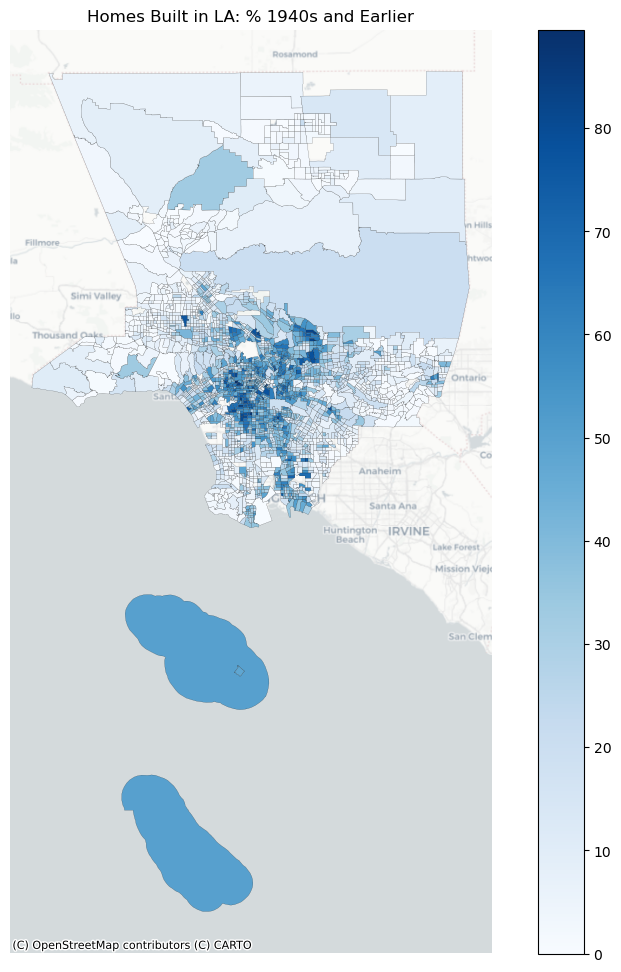

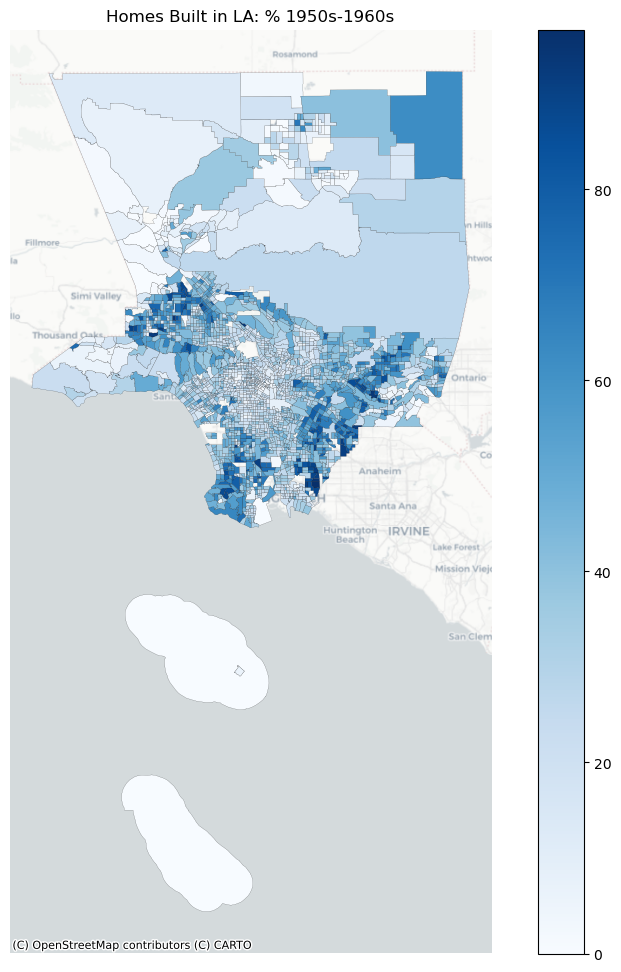

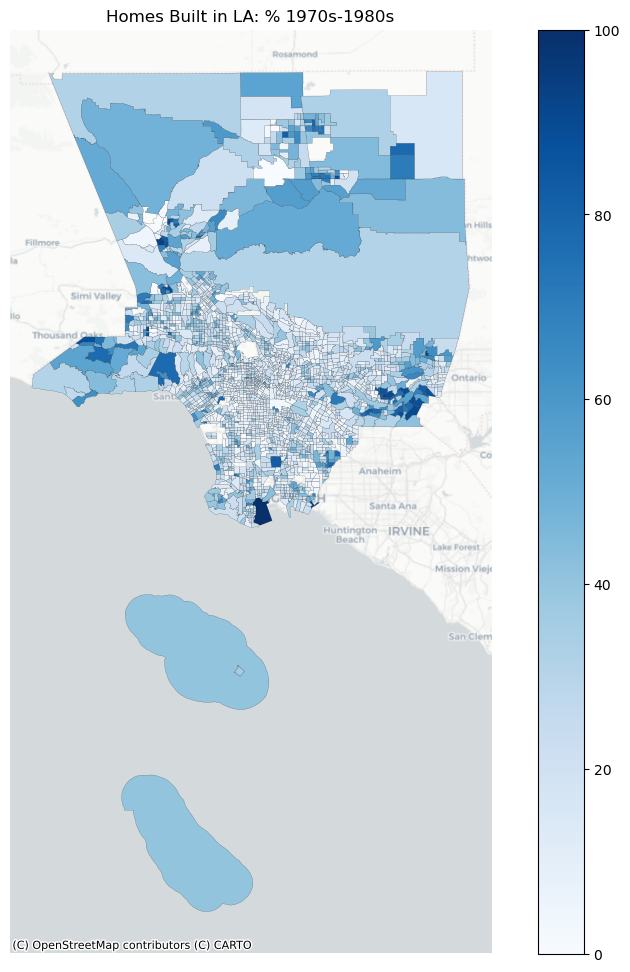

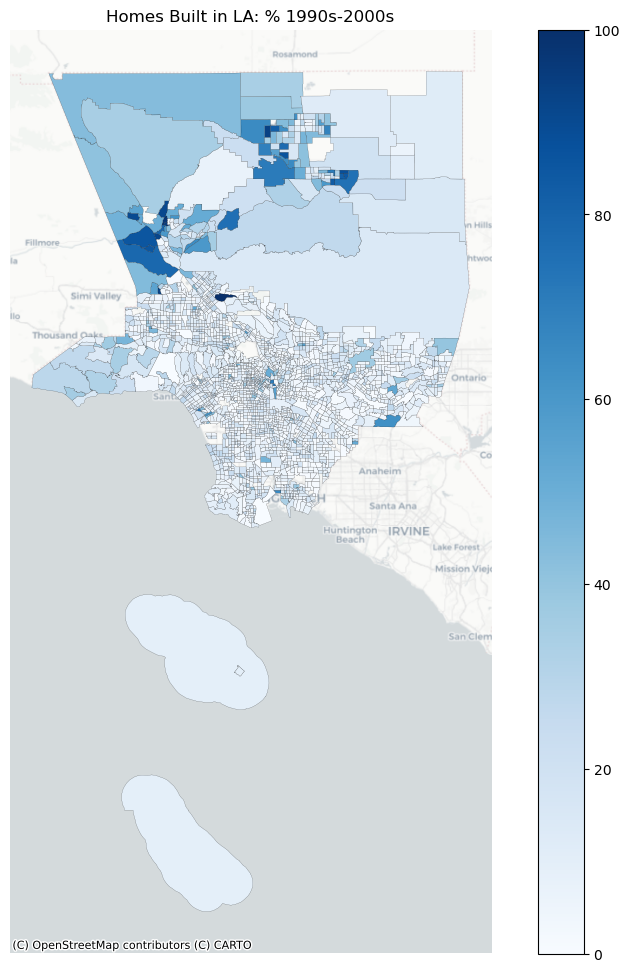

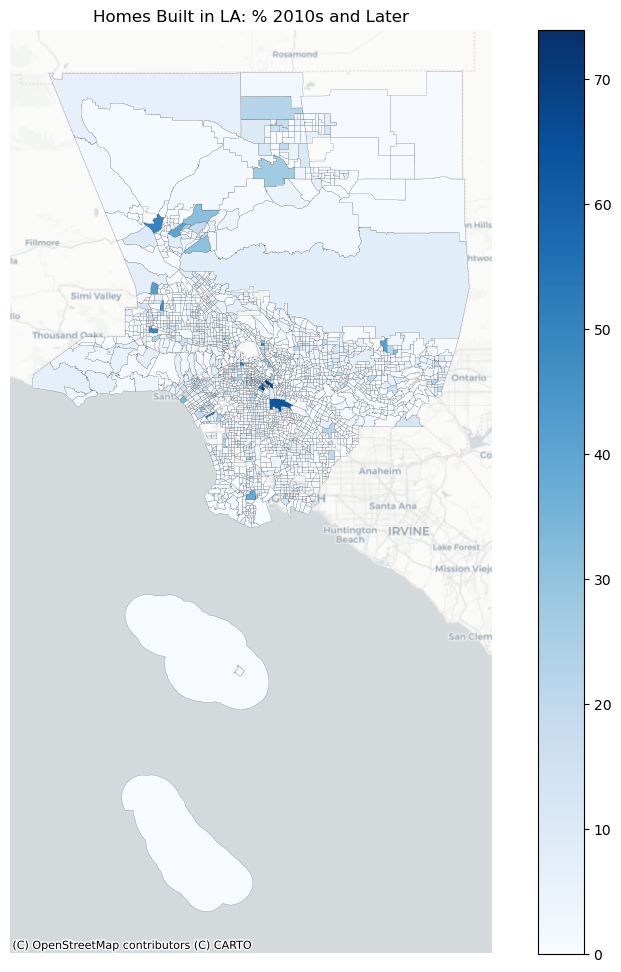

In [40]:
def housing_map(gdf, colors): 

    # select numeric columns for plotting
    numeric_columns = gdf.select_dtypes(include=['float64']).columns

    # loop over numeric columns 
    for vintage in numeric_columns:
        
        fig,ax = plt.subplots(figsize=(12,12))
        gdf.plot(ax=ax,
                 legend=True,
                 column=vintage,
                 cmap=colors,
                 ec='black', 
                 linewidth=0.1)

        ctx.add_basemap(ax, crs=4269, source=ctx.providers.CartoDB.Positron) 

        ax.axis('off'); # axis off
        ax.set_title(f"{'Homes Built in LA'}: {vintage}"); # title

# call function
housing_map(tracts_vintage, 'Blues')

# save map
#plt.savefig('Completed Maps/oldHomes.jpg')

Note to self: the next iteration will include scatterplots: https://plotly.com/python/linear-fits/